In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
features = pd.read_csv(r"D:\User1\deficreditscore\wallet_features.csv")
scores = pd.read_csv(r"D:\User1\deficreditscore\wallet_scores.csv")
df = features.merge(scores, on="wallet")

In [3]:
X = df.drop(columns=["wallet", "score"])
y = df["score"]

In [4]:
X = X.fillna(0)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [7]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [8]:
print(f"✅ Model Trained")
print(f"📊 MSE: {mse:.2f}")
print(f"📈 R² Score: {r2:.4f}")


✅ Model Trained
📊 MSE: 287.12
📈 R² Score: 0.9919


In [9]:
importances = model.feature_importances_
feat_names = X.columns
fi_df = pd.DataFrame({"feature": feat_names, "importance": importances})
fi_df = fi_df.sort_values(by="importance", ascending=False)

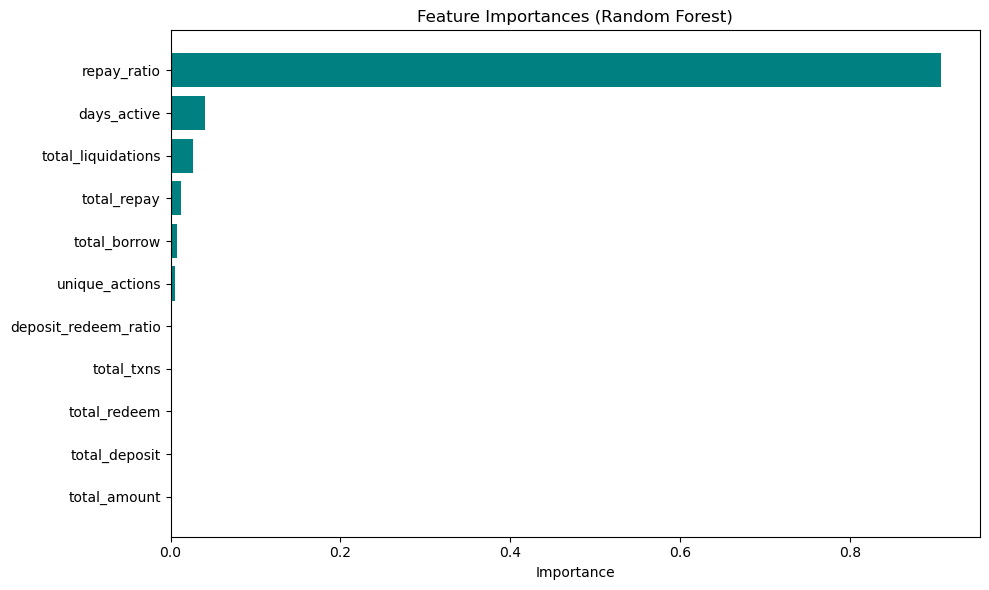

In [10]:
plt.figure(figsize=(10, 6))
plt.barh(fi_df["feature"], fi_df["importance"], color='teal')
plt.xlabel("Importance")
plt.title("Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

In [11]:
import joblib
joblib.dump(model, "rf_credit_score_model.pkl")

['rf_credit_score_model.pkl']